In [1]:
import psi4
import numpy as np
# ─────────────────────────────────────────────
# Psi4 basic config
# ─────────────────────────────────────────────
psi4.set_memory("10 GB")
psi4.set_num_threads(2)
psi4.set_output_file("psi4_env_check.out", False)
psi4.core.clean()
psi4.core.clean_options()



  Memory set to   9.313 GiB by Python driver.
  Threads set to 2 by Python driver.


In [2]:
# Distances along z-axis for Br
br_distances = np.linspace(1.75, 2.75, 50)  # 20 points between 1.4 and 4.0 Å
energies = []

#br_distances = [4.0]
# Geometry of nitrobenzene without Br
base_geom = """
1 1
C      -1.88594687      1.18958365     -0.11972613
C      -0.49843615      1.20775699     -0.09558767
C       0.17702290      0.00124442      0.00317078
C      -2.57032081     -0.01893081     -0.04607635
H      -2.43349075      2.12201469     -0.19650246
H       0.06174270      2.13150887     -0.15114950
H      -3.65476023     -0.02696528     -0.06553951
N       1.65323499      0.01218731      0.02955711
O       2.22153345     -1.05706033      0.11543382
O       2.20819882      1.08981974     -0.03621077
C      -1.87128795     -1.21727903      0.05246299
H      -2.40753951     -2.15765116      0.10975301
C      -0.48368407     -1.21509221      0.07816890
H       0.08763274     -2.13046530      0.15459657
"""

# Psi4 options
psi4.set_options({"basis": "6-311G*",
                  "reference": "rks",
                  "scf_type": "df",
                  "e_convergence": 1e-9,
                  "d_convergence":1e-9,
                  "dft_radial_points": 99,
                  "dft_spherical_points": 590,
                  "dft_pruning_scheme": "none"
                 })

for z in br_distances:
    geom_str = base_geom + f"Br 0.000000 0.000000 {z:.3f}\nunits angstrom\nsymmetry c1"
    mol = psi4.geometry(geom_str)
    e = psi4.energy("wb97x-d", molecule=mol)
    energies.append(e)
    print(f"Distance {z:.2f} Å: Energy = {e:.8f} Hartree")

# UKS results
#Distance 2.00 Å: Energy = -3010.34004850 Hartree
#Distance 2.50 Å: Energy = -3010.41880905 Hartree
#Distance 3.00 Å: Energy = -3010.42316702 Hartree
#Distance 3.50 Å: Energy = -3010.41105499 Hartree



Distance 1.75 Å: Energy = -3010.40839649 Hartree
Distance 1.77 Å: Energy = -3010.41658406 Hartree
Distance 1.79 Å: Energy = -3010.42444365 Hartree
Distance 1.81 Å: Energy = -3010.43127250 Hartree
Distance 1.83 Å: Energy = -3010.43780811 Hartree
Distance 1.85 Å: Energy = -3010.44345981 Hartree
Distance 1.87 Å: Energy = -3010.44859418 Hartree
Distance 1.89 Å: Energy = -3010.45347514 Hartree
Distance 1.91 Å: Energy = -3010.45766378 Hartree
Distance 1.93 Å: Energy = -3010.46161127 Hartree
Distance 1.95 Å: Energy = -3010.46497268 Hartree
Distance 1.97 Å: Energy = -3010.46797277 Hartree
Distance 1.99 Å: Energy = -3010.47076092 Hartree
Distance 2.02 Å: Energy = -3010.47309573 Hartree
Distance 2.04 Å: Energy = -3010.47523436 Hartree
Distance 2.06 Å: Energy = -3010.47699407 Hartree
Distance 2.08 Å: Energy = -3010.47857197 Hartree
Distance 2.10 Å: Energy = -3010.47983644 Hartree
Distance 2.12 Å: Energy = -3010.48088551 Hartree
Distance 2.14 Å: Energy = -3010.48177238 Hartree
Distance 2.16 Å: Ene

In [3]:
#br_distances = np.linspace(2.0, 4.0, 5)  # 20 points between 1.4 and 4.0 Å

# 2️⃣ Find minimum distance from the scan
min_index_s = np.argmin(energies)
min_distance = br_distances[min_index_s]
print(f"\nApproximate minimum for RKS singlates at z = {min_distance:.2f} with energy {energies[min_index_s]:.8f} Hartree")

#min_index_s_uks = np.argmin(energies_sing_uks)
#min_distance_s_uks = br_distances[min_index_s_uks]
#print(f"\nApproximate minimum for UKS singlates at z = {min_distance_s_uks:.2f} with energy {energies[min_index_s_uks]:.8f} Hartree")

#min_index_t = np.argmin(energies_triplet)
#min_distance_t = br_distances[min_index_t]
#print(f"\nApproximate minimum for triplates at z = {min_distance_t:.2f} with energy {energies_triplet[min_index_t]:.8f} Hartree")



# 3️⃣ Single-point calculation at 6-311G* at the minimum
#psi4.set_options({"basis": "6-311G*",
#                  "reference": "uhf",
#                  "scf_type": "df",
#                  "e_convergence": 1e-6})

# min_geom = base_geom + f"Br 0.000000 0.000000 {min_distance:.3f}\nunits angstrom\nsymmetry c1"
# min_mol = psi4.geometry(min_geom)
# e_6311G = psi4.energy("b3lyp", molecule=min_mol)
# print(f"\nSingle-point energy at minimum with 6-311G* for = {e_6311G:.8f} Hartree")




Approximate minimum for RKS singlates at z = 2.24 with energy -3010.48346926 Hartree


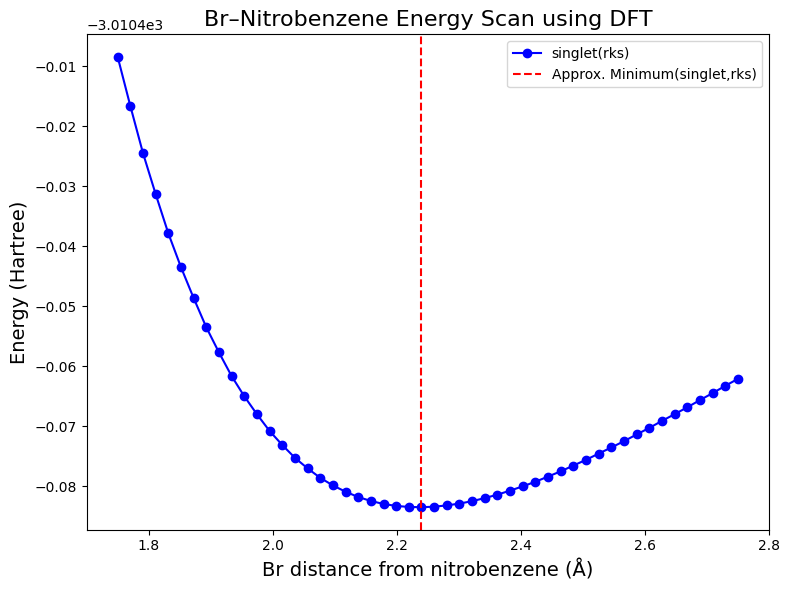

In [4]:
import matplotlib.pyplot as plt
# 4️⃣ Plot scan
plt.figure(figsize=(8,6))
plt.plot(br_distances, energies, marker='o', linestyle='-', color='b', label='singlet(rks)')
#plt.plot(br_distances, energies_sing_uks, marker='s', linestyle='--', color='g', label='singlet(uks)')
plt.axvline(min_distance, color='r', linestyle='--', label='Approx. Minimum(singlet,rks)')
#plt.axvline(min_distance_s_uks, color='m', linestyle='--', label='Approx. Minimum (singlet,uks)')
plt.xlabel("Br distance from nitrobenzene (Å)", fontsize=14)
plt.ylabel("Energy (Hartree)", fontsize=14)
plt.title("Br–Nitrobenzene Energy Scan using DFT", fontsize=16)
#plt.savefig("/Users/rmandern/code/md-cqed/br_nitrobenzene_wb97xd_uks.png", dpi=300)
# plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(energies)